# Overlay Coordinate Grids

Every point on the sky has more than one address. The Crab Nebula is at
RA 5ʰ34ᵐ, Dec +22° in the equatorial system — *and* at galactic longitude
*l* ≈ 184.6°, latitude *b* ≈ −5.8°, just below the plane of the Milky Way.
Same point, two coordinate systems. A figure often needs to show **both**: an
equatorial map (because that's how the data were taken) with a galactic
graticule drawn over it (because that's where the science is).

This tutorial is about drawing that *second* coordinate system's grid, ticks,
and labels over a frame **without converting any data** — answering the two
questions every overlay raises: **"how do I show a second system's grid?"** and
**"how do I adjust where and how it's drawn?"**

> **Scope:** this is about a second *coordinate grid*. Converting your
> *catalog's* coordinates from one system to another (dropping an *l*/*b* source
> list onto an equatorial map) is a data operation — see
> [Catalogs — Querying, Plotting and Searching](catalogs.ipynb) for
> `plot_catalog(frame=...)`. Here, no data moves; only a second
> graticule is laid on top. For a frame's **own** ticks, grid, and labels, see
> [Decorating Frames](decorating_frames.ipynb).

## Contents

1. [The one-call overlay](#1.-The-one-call-overlay)
2. [Choosing and styling the gridlines](#2.-Choosing-and-styling-the-gridlines)
3. [Tick and label placement](#3.-Tick-and-label-placement)
4. [How this compares to astropy](#4.-How-this-compares-to-astropy)
5. [All-sky maps and globes](#5.-All-sky-maps-and-globes)
6. [Putting it together](#6.-Putting-it-together)
7. [Where to go next](#7.-Where-to-go-next)

In [1]:
import astropy.units as u
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.table import Table
from matplotlib.patches import Polygon as MplPolygon

import skyplothelper as sph

# Give the whole notebook a tightened skyplothelper look. base='structural' adjusts
# only frame/tick *geometry* — it leaves colors and fonts alone, so it composes with
# whatever theme is active (unlike base='standard', which resets to the light theme).
sph.set_style(base="structural")

Throughout we reuse a few recurring **data anchors** so the focus stays on the
overlay, not the data:

- an **all-sky equatorial (ICRS) map** — the host for a galactic or ecliptic
  graticule;
- a **tilted celestial globe** — where an overlay grid curves and its labels
  have to follow;
- a **zoomed field on the Crab Nebula (M1)** — the everyday "here is one source,
  shown in both systems" picture.

The galactic overlay is the running example because it is useful for many all-sky
visualizations; everything below works for `'ecliptic'`, `'fk5'`, `'supergalactic'`,
and the rest just by changing the frame name.

In [2]:
# Recurring anchors.
CRAB = (83.6287, 22.0147)                    # RA, Dec of M1 (deg) — galactic (184.6, -5.8)
NGP = (192.8595, 27.1283)                    # North Galactic Pole in ICRS (deg)

# A quiet gray, dotted main graticule lets the solid colored overlay read as the
# prominent layer (a look borrowed from the kapteyn package's atlas figures).
# OVERLAY_LW is the overlay line width used across the (non-raster) figures.
OVERLAY_LW = 1.2


def overlay_host(ax):
    """Style the primary graticule as a quiet gray, dotted grid so the solid colored
    overlay is the obviously prominent layer. The solid frame spine is left as the
    theme sets it. Call after the figure is drawn."""
    sph.style_grid(ax, color="0.5", lw=0.6, ls=":", alpha=1.0)
    return ax


def allsky_icrs(subplot=111, center=180, fig=None, **kw):
    """An ICRS all-sky Aitoff map — recurring overlay host, grid pre-styled."""
    ax = sph.make_wcs_frame(subplot, "AIT", center=center, frame="ICRS",
                            fig=fig, **kw)
    ax.figure.canvas.draw()
    return overlay_host(ax)


def crab_tan(subplot=111, fov_deg=6.0, fig=None, **kw):
    """A tangent field on the Crab (M1) — the 'your own image' host, grid pre-styled."""
    ax = sph.make_wcs_frame(subplot, "TAN", center=CRAB, fov_deg=fov_deg,
                            fig=fig, **kw)
    # Trim the readout to the field scale (drop the redundant trailing 00.00s / 00'00").
    ax.coords[0].set_major_formatter("hh:mm")
    ax.coords[1].set_major_formatter("dd")
    ax.figure.canvas.draw()
    return overlay_host(ax)


# Overlay colors come from the sph 'uranometria' cycle palette — a dual-mode
# palette whose muted tones read on both the light and dark docs pages. The
# galactic grid takes a warm red (it stands out against the bluish dark-mode frame,
# where a blue overlay would not), and the ecliptic (and the second gridline family
# in Section 2) a green. Frame colors themselves are left unmodified — the docs
# light/dark generation gives them suitable values.
URAN = sph.CYCLE_PALETTES["uranometria"]["colors"]
GAL = URAN[5]       # warm red — galactic overlay
ECL = URAN[4]       # green    — ecliptic overlay / second gridline family
BOX_HL = URAN[0]    # blue     — the highlighted inset box (§3): outline, grid, labels


# A Milky Way panorama for the two raster figures (the overlay over the real sky in
# Section 1, and the capstone). Loaded in galactic layout so it reprojects correctly
# onto an equatorial frame.
PANORAMA = "../../examples/data/Allsky_noirlab2430b_1280x640.jpg"
_pano_img, _pano_hdr = sph.load_sky_image(PANORAMA, frame="galactic", center=0)


def milkyway_backdrop(ax, alpha=0.75):
    """Drape the Milky Way panorama under an ICRS all-sky frame. The primary grid and
    RA labels take the frame color, so they follow whatever theme is active and stay
    readable over the image's dark sky. Rasters keep a normal-weight frame (the thin,
    quiet-host look is for the line-art figures). Build the host with a fine npix
    (e.g. (1200, 600)) for a crisp backdrop."""
    fr = ax.coords.frame
    fr.set_linewidth(0.7)
    col = fr.get_color()
    sph.style_grid(ax, color=col, lw=0.7, ls="-", alpha=1.0)
    ax.coords[0].set_ticks(color=col)
    ax.coords[0].set_ticklabel(color=col)
    ax.imshow(sph.reproject_background(_pano_img, _pano_hdr, ax), zorder=-10, alpha=alpha)


def light_stroke(lw):
    """A light ('0.9') stroke, for overlay lines/labels drawn over the bright image."""
    return [pe.withStroke(linewidth=lw, foreground="0.9")]

Here is the idea in one figure. On the **left**, the whole sky on an equatorial
(ICRS) frame, with a galactic graticule drawn over it in red — the same sky,
addressed two ways. On the **right**, a zoom onto the Crab Nebula: read its
RA/Dec off the frame edge, and its galactic *l*/*b* off the in-frame red
grid. The two systems meet at the source, and the data never had to move. The
rest of the tutorial is how to draw, style, and place that second grid.

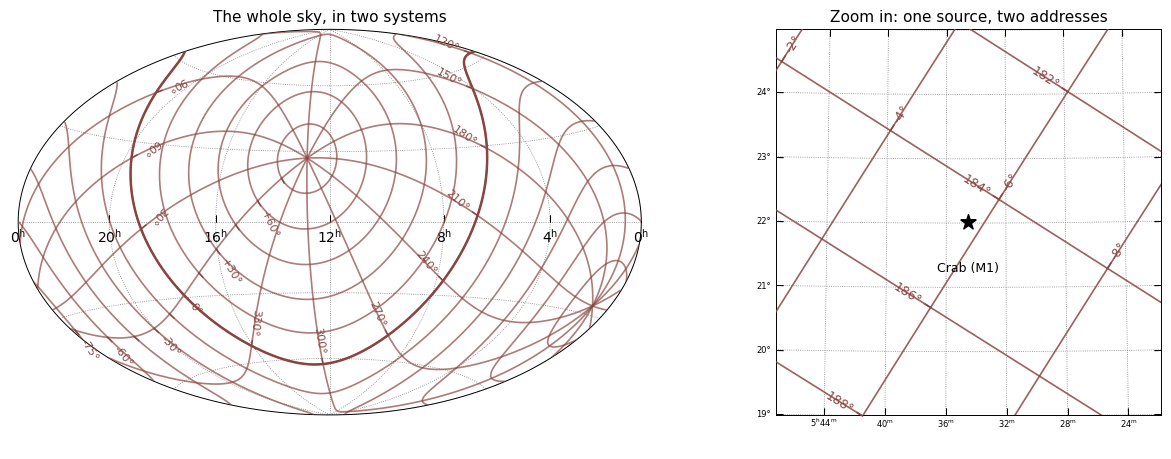

In [3]:
# fig-slug: overview
fig = plt.figure(figsize=(13, 4.7))

# Left: the whole sky in two systems.
axL = allsky_icrs((1, 2, 1), fig=fig)
sph.add_coord_overlay(axL, frame="galactic", color=GAL, alpha=0.7, lw=OVERLAY_LW, ls="-")
sph.add_plane_overlay(axL, plane="galactic", color=GAL, lw=1.8)
sph.add_overlay_ticks(axL, frame="galactic", lon_at="axis", lat_at="axis",
                      suppress_default="none",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0),
                      label_kwargs=dict(fontsize=8, color=GAL))
axL.set_title("The whole sky, in two systems", fontsize=11)

# Right: zoom to the Crab — both addresses meet at the source.
axR = crab_tan((1, 2, 2), fig=fig)
sph.add_coord_overlay(axR, frame="galactic", color=GAL, alpha=0.85, lw=OVERLAY_LW, ls="-")
sph.add_overlay_ticks(axR, frame="galactic", lon_at="lat=-6", lat_at="lon=184",
                      suppress_default="none",
                      tick_kwargs=dict(length=6, color=GAL, lw=1.1),
                      label_kwargs=dict(fontsize=9, color=GAL))
# The star takes the frame color so it reads on any theme background.
axR.scatter(*CRAB, transform=axR.get_transform("world"), s=130, marker="*",
            color=axR.coords.frame.get_color(), zorder=5)
axR.text(CRAB[0], CRAB[1] - 0.6, "Crab (M1)", transform=axR.get_transform("world"),
         ha="center", va="top", fontsize=9)
axR.set_title("Zoom in: one source, two addresses", fontsize=11)

fig.tight_layout()

## 1. The one-call overlay

The fastest way to put a second system on a frame is `add_second_grid`. Pick an
`overlay_frame=`, and it draws that system's graticule over the current map —
optionally with ticks and labels on the frame boundary. Nothing about the
underlying data or the primary (equatorial) axes changes; the overlay is a layer
on top.

Here the same ICRS Aitoff map carries a **galactic** grid on the left and an
**ecliptic** grid on the right — only the frame name differs. The thicker solid line in
each is that system's equator (the Milky Way's plane; the ecliptic), drawn with
`add_plane_overlay` so the grid has an anchor the eye can latch onto.

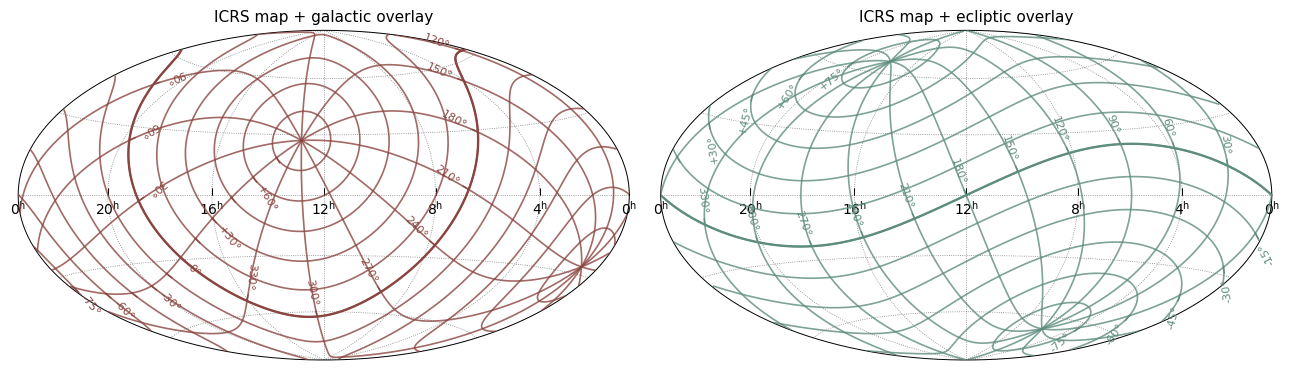

In [4]:
fig = plt.figure(figsize=(13, 3.8))

# Left: a galactic graticule on the ICRS map. The grid comes from add_second_grid;
# the labels are placed in-frame (along the galactic equator + central meridian).
ax1 = allsky_icrs((1, 2, 1), fig=fig)
fig.canvas.draw()
sph.add_second_grid(ax1, overlay_frame="galactic", color=GAL, alpha=0.8,
                    linestyle="-", linewidth=OVERLAY_LW, ticks=False, tick_labels=False)
sph.add_plane_overlay(ax1, plane="galactic", color=GAL, lw=1.7)
sph.add_overlay_ticks(ax1, frame="galactic", lon_at="axis", lat_at="axis",
                      suppress_default="none",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0),
                      label_kwargs=dict(fontsize=8, color=GAL))
ax1.set_title("ICRS map + galactic overlay", fontsize=11)

# Right: the same recipe for the ecliptic — only the frame name changes.
ax2 = allsky_icrs((1, 2, 2), fig=fig)
fig.canvas.draw()
sph.add_second_grid(ax2, overlay_frame="ecliptic", color=ECL, alpha=0.8,
                    linestyle="-", linewidth=OVERLAY_LW, ticks=False, tick_labels=False)
sph.add_plane_overlay(ax2, plane="ecliptic", color=ECL, lw=1.7)
sph.add_overlay_ticks(ax2, frame="ecliptic", lon_at="axis", lat_at="axis",
                      suppress_default="none",
                      tick_kwargs=dict(length=5, color=ECL, lw=1.0),
                      label_kwargs=dict(fontsize=8, color=ECL))
ax2.set_title("ICRS map + ecliptic overlay", fontsize=11)

fig.tight_layout()

**The knobs.** `add_second_grid(ax, overlay_frame=...)` takes any astropy frame
name (`'galactic'`, `'ecliptic'`, `'fk5'`, `'supergalactic'`, …) and a handful of
style controls:

- `color`, `alpha`, `linestyle`, `linewidth` — the graticule's look (pick a tone
  that *contrasts* with the primary grid so the two systems read apart);
- `grid=` / `ticks=` / `tick_labels=` — independent toggles for the curves and for
  ticks/labels on the frame boundary.

Above, the grid comes from `add_second_grid`, and the *labels* are placed
**in-frame** — running along each system's own equator and central meridian — with
`add_overlay_ticks(..., lon_at="axis", lat_at="axis")`. In-frame is usually the
clearer choice for a second system, because the frame *edge* still belongs to the
primary (equatorial) coordinates; [Section 3](#3.-Tick-and-label-placement) is the
full story on placing overlay labels on the boundary versus in-frame.

> **Note:** `'ecliptic'` is a convenience alias for astropy's
> `'geocentrictrueecliptic'`; either name works.

### The overlay over the real sky

The galactic grid is not an arbitrary set of curves — it traces the Milky Way you
can actually see. Drape the NOIRLab all-sky panorama under the same ICRS frame, and
the galactic equator (*b* = 0) runs straight down the luminous band of the Galaxy.
Over a bright image the overlay needs a little legibility help: a thin light stroke
on its lines and labels. (Here the panorama is just a photographic backdrop; we add
a real data layer in the [capstone](#6.-Putting-it-together).)

Text(0.5, 1.0, 'The galactic graticule traces the Milky Way (NOIRLab panorama)')

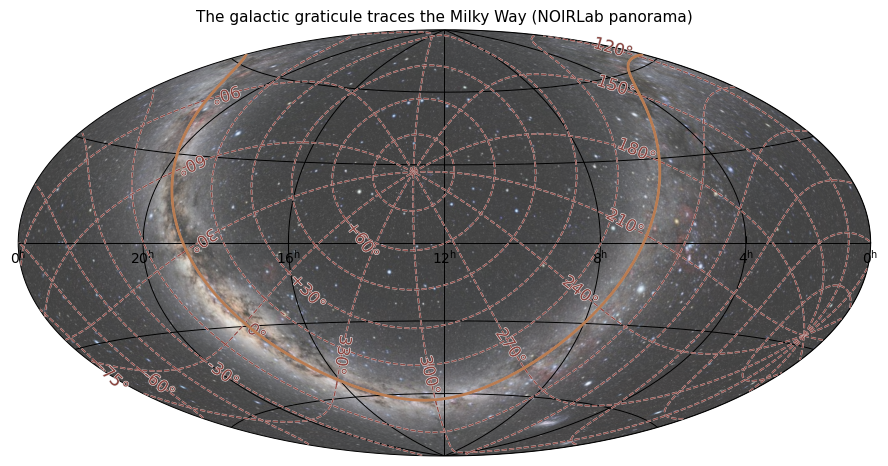

In [5]:
fig = plt.figure(figsize=(11, 5.6))
ax = allsky_icrs(111, fig=fig, npix=(1200, 600))
milkyway_backdrop(ax, alpha=0.75)
sph.add_coord_overlay(ax, frame="galactic", color=GAL, alpha=0.95, lw=1.0, ls="--",
                      path_effects=light_stroke(1.3))
sph.add_plane_overlay(ax, plane="galactic", color=URAN[1], lw=2.0,
                      path_effects=light_stroke(1.3))
sph.add_overlay_ticks(ax, frame="galactic", lon_at="axis", lat_at="axis",
                      suppress_default="none", stroke_lw=0.8, stroke_color="0.9",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0, direction="in"),
                      label_kwargs=dict(fontsize=12, color=GAL))
ax.set_title("The galactic graticule traces the Milky Way (NOIRLab panorama)",
             fontsize=11)

## 2. Choosing and styling the gridlines

`add_second_grid` is the quick path; `add_coord_overlay` is the configurable one.
It draws the same overlay graticule but lets you choose **exactly which**
meridians and parallels appear (`lon_vals=`, `lat_vals=`) and style the two
families **independently** (`lon_style=`, `lat_style=`). Use it when the default
30°/15° graticule is too dense, or when you want the meridians and parallels to
read differently.

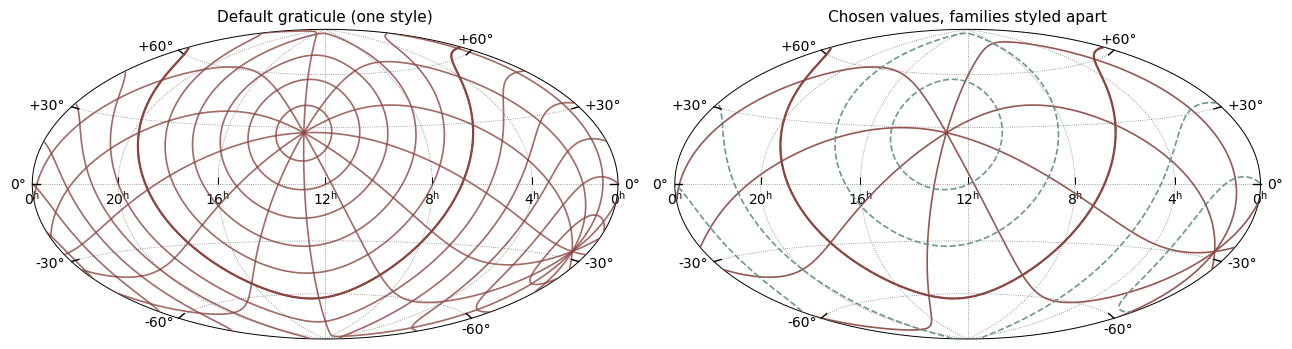

In [6]:
fig = plt.figure(figsize=(13, 3.6))

# Left: the default graticule — every 30° in l, every 15° in b, one style.
axa = allsky_icrs((1, 2, 1), fig=fig)
fig.canvas.draw()
sph.add_coord_overlay(axa, frame="galactic", color=GAL, alpha=0.8, lw=OVERLAY_LW, ls="-")
sph.add_plane_overlay(axa, plane="galactic", color=GAL, lw=1.6)
axa.set_title("Default graticule (one style)", fontsize=11)

# Right: a chosen, sparser set with the two families styled apart.
axb = allsky_icrs((1, 2, 2), fig=fig)
fig.canvas.draw()
sph.add_coord_overlay(
    axb, frame="galactic",
    lon_vals=np.arange(0, 360, 45),          # meridians every 45°
    lat_vals=[-60, -30, 0, 30, 60],          # a handful of parallels
    lon_style=dict(color=GAL, lw=OVERLAY_LW, ls="-", alpha=0.9),    # meridians: solid red
    lat_style=dict(color=ECL, lw=OVERLAY_LW, ls="--", alpha=0.9))   # parallels: dashed green
sph.add_plane_overlay(axb, plane="galactic", color=GAL, lw=1.6)
axb.set_title("Chosen values, families styled apart", fontsize=11)

fig.tight_layout()

**The object underneath.** Both `add_second_grid` and `add_coord_overlay` return
a `CoordinateOverlay`, which is the layer you can keep configuring. The
convenience functions call its steps for you; reach for the object directly when
you want full control over the sequence:

```python
(sph.CoordinateOverlay(ax, frame="galactic",
                       lon_vals=np.arange(0, 360, 30),
                       lat_vals=np.arange(-60, 61, 30))
    .plot(lon_style=..., lat_style=...)   # draw the gridlines
    .discover_ticks()                     # find where gridlines cross the boundary
    .render_ticks(length=6, color=GAL)    # draw tick marks
    .render_labels(fontsize=9, color=GAL))  # draw labels
```

Each step returns the overlay, so they chain. `add_graticule_overlay` is an
alias of `add_coord_overlay` for readers who think in kapteyn's "graticule"
terminology — same function, same arguments.

## 3. Tick and label placement

Section 1 placed the overlay's labels in-frame without dwelling on why. Here is
the full story. `add_overlay_ticks` decides *where* each system's ticks and labels
go, set per-axis with `lon_at=` and `lat_at=`:

- `'boundary'` — on the frame's outer edge (the all-sky ellipse, a globe's rim);
- `'axis'` — along the overlay's own equator (for lon) and central meridian (for
  lat);
- `'lat=N'` / `'lon=N'` — along a chosen in-frame gridline of the overlay system;
- `None` — skip that axis.

The choice matters because **the frame edge belongs to the primary system**. Put
the overlay's labels on the boundary too and the two systems fight for the same
border; put them in-frame and each system reads cleanly:

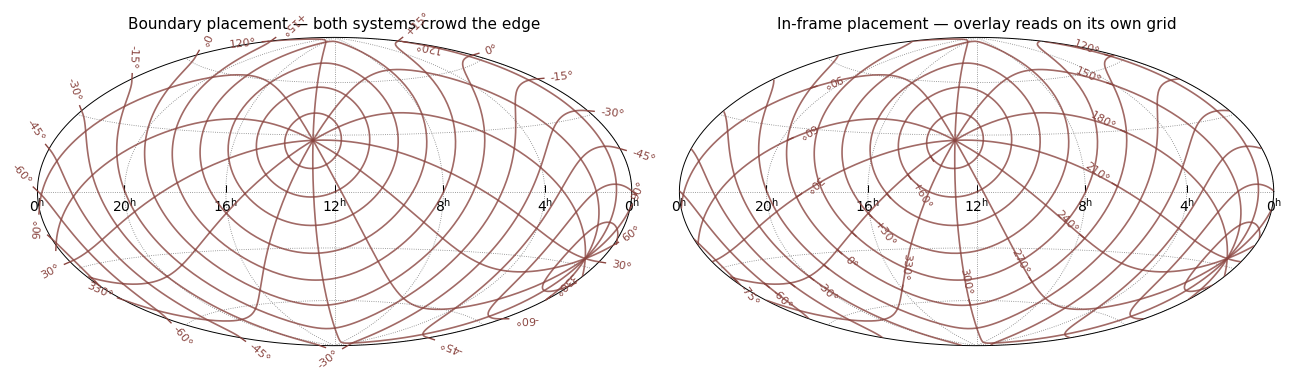

In [7]:
fig = plt.figure(figsize=(13, 3.9))

# Left: boundary placement — the overlay's labels pile onto the edge with the
# primary system's (suppress_default='none' keeps the primary labels visible).
ax1 = allsky_icrs((1, 2, 1), fig=fig)
sph.add_coord_overlay(ax1, frame="galactic", color=GAL, alpha=0.8, lw=OVERLAY_LW, ls="-")
sph.add_overlay_ticks(ax1, frame="galactic", lon_at="boundary", lat_at="boundary",
                      suppress_default="none",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0),
                      label_kwargs=dict(fontsize=8, color=GAL))
ax1.set_title("Boundary placement — both systems crowd the edge", fontsize=11)

# Right: in-frame placement — the overlay's labels move onto its own grid.
ax2 = allsky_icrs((1, 2, 2), fig=fig)
sph.add_coord_overlay(ax2, frame="galactic", color=GAL, alpha=0.8, lw=OVERLAY_LW, ls="-")
sph.add_overlay_ticks(ax2, frame="galactic", lon_at="axis", lat_at="axis",
                      suppress_default="none",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0),
                      label_kwargs=dict(fontsize=8, color=GAL))
ax2.set_title("In-frame placement — overlay reads on its own grid", fontsize=11)

fig.tight_layout()

`suppress_default=` is the companion control: it hides the *primary* system's
default ticks/labels before drawing the overlay's (`'both'`, `'lon'`, `'lat'`, or
`'none'`). Keep it `'none'` when you want both systems labeled (above); set it to
`'both'` to replace the primary readout with the overlay's entirely (a "second
axis sharing the spine" look).

The looks pass through `tick_kwargs=` and `label_kwargs=`: ticks take `length`,
`lw`, `color`, and `direction` (`'in'`/`'out'`); labels take `fontsize`, `color`,
`pad`, `rotate` (`'tangent'` by default, so each label follows its gridline), and
`fmt=`/`sep=` for the number format. `show_ticks=False` / `show_labels=False`
drop either layer entirely.

The same `lon_at`/`lat_at` controls apply to a zoomed image: a galactic *l*/*b*
grid laid in-frame over your own tangent field, with the labels along a gridline
that crosses the view (`'lat=N'` / `'lon=N'`, since the overlay's own equator is
usually off-screen for a small field). That is exactly the recipe behind the Crab
zoom in this tutorial's opening figure.

### A custom boundary box

Beyond the frame edge and in-frame gridlines, `add_overlay_ticks` can label any
**custom boundary curve** passed as `boundary=` — handy for marking a region of
interest and reading the overlay system's coordinates off its edge. The box can be
**aligned to the main frame** (a plain rectangle, left) or **shaped to the overlay
frame** (a galactic *l*/*b* box, which curves on the equatorial map, right); either
way, its edges carry the galactic labels. Here the box, its *contained* gridlines,
and its edge labels are all drawn in **blue** to set the highlighted region off
from the full galactic overlay (red) behind it.

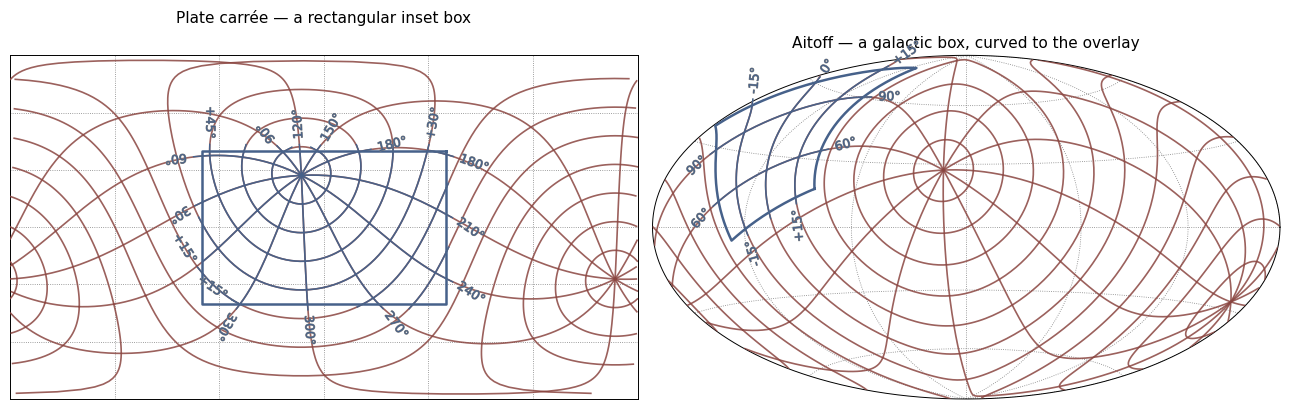

In [8]:
def overlay_box(lon0, lon1, lat0, lat1, n=60, frame=None):
    """A closed, densified box perimeter in world coords. With `frame=`, the box is
    defined in that frame and returned in ICRS — so a galactic box curves correctly
    on the equatorial map."""
    def edge(a, b, c, d):
        return np.column_stack([np.linspace(a, b, n), np.linspace(c, d, n)])
    perim = np.vstack([edge(lon0, lon1, lat1, lat1), edge(lon1, lon1, lat1, lat0),
                       edge(lon1, lon0, lat0, lat0), edge(lon0, lon0, lat0, lat1)])
    if frame is None:
        return perim
    c = SkyCoord(perim[:, 0] * u.deg, perim[:, 1] * u.deg, frame=frame).icrs
    return np.column_stack([c.ra.deg, c.dec.deg])


def boxed_overlay(ax, box, color):
    """Outline the box and label its edges, and redraw the overlay gridlines *inside*
    the box in the same color (clipped to it) — so the box's contained grid visibly
    connects to its edge labels, set off from the full overlay behind it."""
    clip = MplPolygon(box, closed=True, facecolor="none", edgecolor="none",
                      transform=ax.get_transform("world"))
    ax.add_patch(clip)
    inner = sph.add_coord_overlay(ax, frame="galactic", color=color, alpha=0.95,
                                  lw=OVERLAY_LW, ls="-")
    for arts in inner.lon_artists + inner.lat_artists:
        for ln in arts:
            ln.set_clip_path(clip)
    ax.plot(box[:, 0], box[:, 1], transform=ax.get_transform("world"), color=color, lw=1.8)
    sph.add_overlay_ticks(ax, frame="galactic", boundary=box, lon_at="boundary", lat_at="boundary",
                          stroke_lw=0.7, stroke_color="0.5",
                          tick_kwargs=dict(length=6, color=color, lw=1.0),
                          label_kwargs=dict(fontsize=9, color=color))


fig = plt.figure(figsize=(13, 4.2))

# Left: a main-frame-aligned rectangular box on a plate carrée map.
ax1 = sph.make_wcs_frame((1, 2, 1), "CAR", center=180, frame="ICRS", fig=fig)
fig.canvas.draw()
sph.style_grid(ax1, color="0.5", lw=0.6, ls=":", alpha=1.0)
sph.add_coord_overlay(ax1, frame="galactic", color=GAL, alpha=0.85, lw=OVERLAY_LW, ls="-")
boxed_overlay(ax1, overlay_box(110, 250, -40, 40), BOX_HL)
ax1.set_title("Plate carrée — a rectangular inset box", fontsize=11)

# Right: a box defined in galactic coords — it curves to follow the overlay frame.
ax2 = sph.make_wcs_frame((1, 2, 2), "AIT", center=180, frame="ICRS", fig=fig)
fig.canvas.draw()
sph.style_grid(ax2, color="0.5", lw=0.6, ls=":", alpha=1.0)
sph.add_coord_overlay(ax2, frame="galactic", color=GAL, alpha=0.85, lw=OVERLAY_LW, ls="-")
boxed_overlay(ax2, overlay_box(40, 110, -25, 25, frame="galactic"), BOX_HL)
ax2.set_title("Aitoff — a galactic box, curved to the overlay", fontsize=11)

fig.tight_layout()

> **Note:** `boundary=` is also the way to label projections whose visible edge
> isn't the rectangular frame spine — Bonne, polyconic, HEALPix, and the conics —
> by passing the projection's true outline as the boundary curve.

## 4. How this compares to astropy

skyplothelper's overlay is not the only way to draw a second grid. astropy's own
WCSAxes has `ax.get_coords_overlay(frame)`, which returns a `CoordinatesMap` you
can grid and tick:

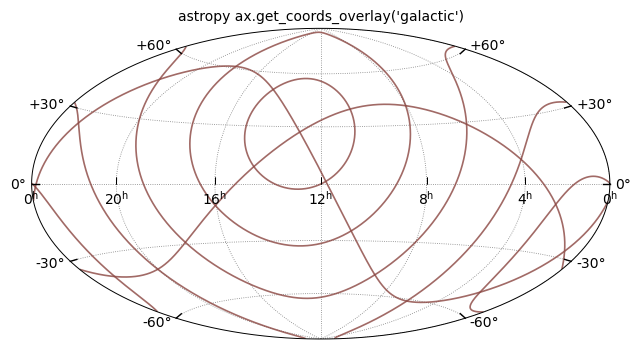

In [9]:
fig = plt.figure(figsize=(6.5, 3.6))
ax = allsky_icrs(111, fig=fig)
fig.canvas.draw()

# astropy's native second-grid: a CoordinatesMap keyed by coordinate name.
overlay = ax.get_coords_overlay("galactic")
overlay.grid(color=GAL, ls="-", alpha=0.8, lw=OVERLAY_LW)
# Hide astropy's overlay ticks AND labels for a clean grid-only comparison (hiding
# the labels alone leaves orphaned tick marks scattered along the frame edge).
for c in ("l", "b"):
    overlay[c].set_ticklabel_visible(False)
    overlay[c].set_ticks_visible(False)
ax.set_title("astropy ax.get_coords_overlay('galactic')", fontsize=10)
fig.tight_layout()

It works, and for a quick grid it's all you need. What the skyplothelper layer
adds, on top of the same idea:

| Capability | astropy `CoordinatesMap` | skyplothelper overlay |
| --- | --- | --- |
| Draw a second graticule | ✓ | ✓ |
| Choose exactly which meridians/parallels | per-coord `set_ticks` | `lon_vals=` / `lat_vals=` |
| Style meridians vs parallels apart | limited | `lon_style=` / `lat_style=` |
| Labels that **follow the curve** (tangent) | — | `render_labels(rotate='tangent')` |
| Place labels **in-frame**, not just on the bbox | — | `lon_at=` / `lat_at=` ([Section 3](#3.-Tick-and-label-placement)) |
| Wrap-seam handling on all-sky frames | — | built in |

The two coexist on one frame — use astropy's for a fast grid, the skyplothelper
helpers when you need control over which curves appear, how the families look,
and *where* the labels sit.

## 5. All-sky maps and globes

Overlays earn their keep on globes and odd projections, where the second system's
grid genuinely *curves* across the frame and a boundary-label readout no longer
makes sense. The in-frame placement from Section 3 carries straight over:
`add_overlay_ticks(..., lon_at="axis", lat_at="axis")` puts the overlay's *l*/*b*
labels along its own equator and central meridian, each rotated to follow the curve.
These globes are busy, so we lean on the prominence levers harder — thin the primary
frame further, **coarsen** its graticule (every 3ʰ in RA, every 30° in Dec), and
draw the galactic overlay **solid** — so the second system stays the clear feature.

Here a tilted celestial globe (a slant-orthographic `SIN` frame) carries a galactic
graticule; the right panel looks straight down the north galactic pole.

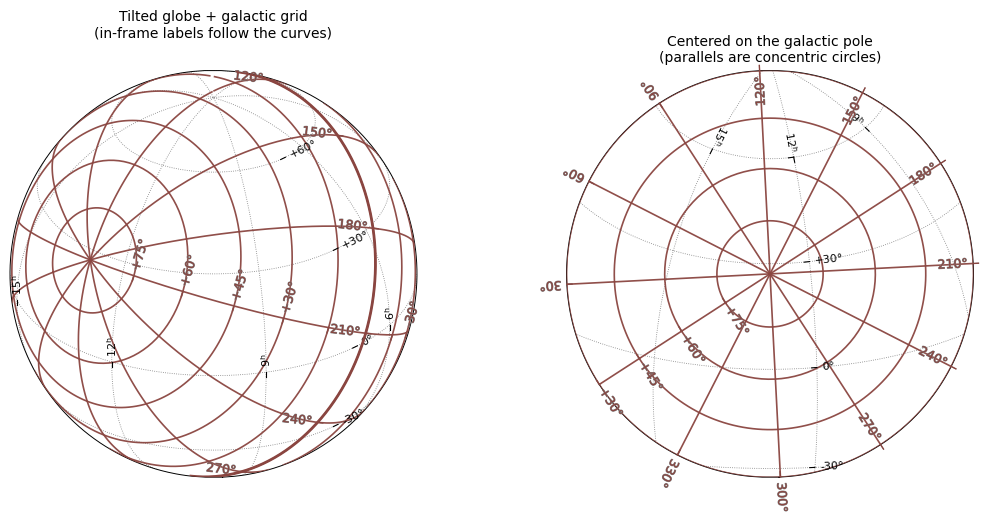

In [10]:
fig = plt.figure(figsize=(11, 5.2))

# Left: a tilted globe. center=(150, 30) rolls the bold galactic plane off the exact
# center so it reads clearly. The default tick style gives clean curved primary labels;
# the coarse (3ʰ / 30°) gray dotted graticule keeps it quiet, and the solid red galactic
# overlay carries the figure — lon labels along its equator, lat labels along a
# front-side meridian.
axg = sph.make_wcs_frame((1, 2, 1), "SIN", center=(150, 30), fig=fig,
                         lon_spacing=45, lat_spacing=30)
fig.canvas.draw()
overlay_host(axg)
# Move the primary labels out of the way: RA along an off-center parallel, Dec along
# an off-center meridian. Replacing both auto families (and matching the grid spacing)
# keeps them on the grid lines and clear of the center. The frame color keeps them
# theme-adaptive.
_pc = axg.coords.frame.get_color()
sph.add_overlay_ticks(axg, lon_at="lat=0", lat_at="lon=105",
                      lon_vals=np.arange(0, 360, 45), lat_vals=np.arange(-60, 61, 30),
                      tick_kwargs=dict(length=5, color=_pc, lw=0.8, direction="in"),
                      label_kwargs=dict(fontsize=8, color=_pc))
sph.add_coord_overlay(axg, frame="galactic", color=GAL, alpha=0.95, lw=OVERLAY_LW, ls="-")
sph.add_plane_overlay(axg, plane="galactic", color=GAL, lw=2.0)
# A very fine gray stroke keeps the red overlay labels legible over the red gridlines.
sph.add_overlay_ticks(axg, frame="galactic", lon_at="axis", lat_at="lon=210",
                      suppress_default="none", stroke_lw=0.7, stroke_color="0.5",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0, direction="in"),
                      label_kwargs=dict(fontsize=9, color=GAL))
axg.set_title("Tilted globe + galactic grid\n(in-frame labels follow the curves)",
              fontsize=10)

# Right: looking straight down the galactic pole — parallels become concentric
# circles, meridians radiate. An ICRS ZEA centered on the North Galactic Pole.
axp = sph.make_wcs_frame((1, 2, 2), "ZEA", center=NGP, fov_deg=180.0, fig=fig,
                         frame="ICRS", lon_spacing=45, lat_spacing=30)
fig.canvas.draw()
overlay_host(axp)
_pc = axp.coords.frame.get_color()
sph.add_overlay_ticks(axp, lon_at="lat=60", lat_at="lon=180",
                      lon_vals=np.arange(0, 360, 45), lat_vals=np.arange(-30, 91, 30),
                      tick_kwargs=dict(length=5, color=_pc, lw=0.8, direction="in"),
                      label_kwargs=dict(fontsize=8, color=_pc))
sph.add_coord_overlay(axp, frame="galactic", color=GAL, alpha=0.95, lw=OVERLAY_LW, ls="-")
sph.add_plane_overlay(axp, plane="galactic", color=GAL, lw=2.0)
sph.add_overlay_ticks(axp, frame="galactic", lon_at="lat=30", lat_at="axis",
                      suppress_default="none", stroke_lw=0.7, stroke_color="0.5",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0, direction="in"),
                      label_kwargs=dict(fontsize=9, color=GAL))
axp.set_title("Centered on the galactic pole\n(parallels are concentric circles)",
              fontsize=10)

fig.tight_layout()

**Longitude labels that follow the curve.** On a globe the overlay labels must
track the bending meridians; `add_overlay_ticks` does this by default
(`rotate='tangent'`), and `lon_at='lat=N'` pins the longitude readout to whichever
parallel of the overlay system crosses the view best.

> **Note:** on a globe the *primary* frame's labels are an in-frame problem too —
> that side of the story (including `add_curved_lon_ticks`, the one-liner that
> runs the primary frame's longitude labels along one of its own parallels) lives
> in [Decorating Frames](decorating_frames.ipynb) §5.

## 6. Putting it together

Time to put the overlay on real data, over the real sky. We drape the Milky Way
panorama under an equatorial map, lay the galactic graticule on top, and add the
**Messier catalog** — 110 objects in equatorial coordinates. The overlay sorts the
two kinds of Messier object by galactic latitude: the Milky Way's own clusters and
nebulae (gold) crowd the galactic plane — the bright band itself — while the
external galaxies (blue squares) shun it entirely, the **zone of avoidance**, where
dust in that band hides the universe beyond. (In this catalog *every* Messier galaxy
lies more than 20° off the plane; seven in ten of the Milky Way objects fall within
it.) The data never moved — the overlay and backdrop together let you read each
object's galactic address and *see* why the galaxies avoid the band.

Text(0.5, 1.0, 'The Messier catalog over the Milky Way, read in galactic coordinates')

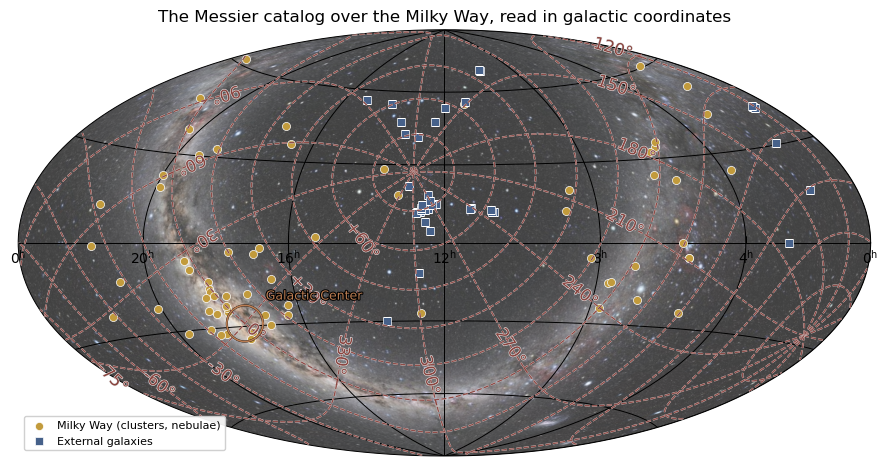

In [11]:
mess = Table.read("../../examples/data/messier.csv")
otype = np.array(mess["otype"])
GALAXY_TYPES = {"AGN", "Galaxy", "GinPair", "GtowardsCl", "GtowardsGroup",
                "HIIG", "LINER", "Seyfert", "Seyfert2", "StarburstG"}
keep = ~np.isin(otype, ["Inexistent", "Unknown"])      # drop two non-objects
is_galaxy = np.array([t in GALAXY_TYPES for t in otype])
mw_objects = mess[keep & ~is_galaxy]
galaxies = mess[keep & is_galaxy]

fig = plt.figure(figsize=(11, 5.8))
ax = allsky_icrs(111, fig=fig, npix=(1200, 600))
milkyway_backdrop(ax, alpha=0.75)

# The galactic graticule — the second address system — with in-frame labels.
sph.add_coord_overlay(ax, frame="galactic", color=GAL, alpha=0.95, lw=1.0, ls="--",
                      path_effects=light_stroke(1.3))
sph.add_overlay_ticks(ax, frame="galactic", lon_at="axis", lat_at="axis",
                      suppress_default="none", stroke_lw=0.8, stroke_color="0.9",
                      tick_kwargs=dict(length=5, color=GAL, lw=1.0, direction="in"),
                      label_kwargs=dict(fontsize=12, color=GAL))

# The Messier objects — the data stays in its own equatorial coordinates.
sph.plot_catalog(ax, mw_objects, ra_col="ra_deg", dec_col="dec_deg",
                 color=URAN[2], s=34, alpha=1.0, edgecolors="white", linewidths=0.5,
                 label="Milky Way (clusters, nebulae)")
sph.plot_catalog(ax, galaxies, ra_col="ra_deg", dec_col="dec_deg",
                 color=URAN[0], marker="s", s=30, alpha=1.0, edgecolors="white",
                 linewidths=0.5, label="External galaxies")

# A reticle on the Galactic Center — where all the galactic meridians converge.
sph.add_reticle(ax, (266.405, -28.936), style="circle", size=13, color=URAN[1],
                stroke_color="black", stroke_lw=1.5, label="Galactic Center",
                label_color=URAN[1], label_fontsize=9,
                label_kwargs=dict(path_effects=[pe.withStroke(linewidth=1.5,
                                                              foreground="black")]))
ax.legend(loc="lower left", fontsize=8, framealpha=0.92)
ax.set_title("The Messier catalog over the Milky Way, read in galactic coordinates",
             fontsize=12)

That is the whole idea of a coordinate overlay: **one sky, two addresses**, with
the data left untouched. Two directions from here:

- **Grid vs. data.** Here the *grid* is galactic and the *data* stay equatorial.
  If a catalog instead arrives already *in* galactic coordinates and you want it on
  an equatorial map, that's a data conversion — `plot_catalog(..., frame="galactic")`
  — the data-side mirror of this notebook, covered in
  [Catalogs — Querying, Plotting and Searching](catalogs.ipynb).
- **Your own field.** The same overlay works zoomed in: drop a galactic *l*/*b*
  grid over your own tangent image with in-frame labels (Section 3), so every
  source carries both addresses at once.

## 7. Where to go next

This tutorial drew a second coordinate *grid* over a frame. The natural next
steps:

| If you want to… | Go to |
| --- | --- |
| style the frame's **own** ticks, grid, and labels | [Decorating Frames](decorating_frames.ipynb) |
| convert a **catalog's** coords between systems (plot *l*/*b* data on an equatorial map) | [Catalogs — Querying, Plotting and Searching](catalogs.ipynb) |
| understand the projection/frame landscape the overlay sits on | [A Tour of Projections](projections.ipynb) |
| draw planes, great circles, and regions as data | [Regions & Spherical Polygons](regions.ipynb) |

Reference: the second-coordinate overlay helpers are documented in the
[Ticks, grids & labels guide](../guide/ticks.md) (§ "Second coordinate systems").